**Классификация: превышает ли значение SI значение 8**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix


# Наш датасет почищенный с анализа EDA
df = pd.read_csv('drugs_fin_clean.csv')

# выделяем таргет  - SI так же удалим как признак через который можно выразить наш таргет
X = df.drop(columns=['CC50, mM','SI','IC50, mM'], axis=1) 
y_raw = np.exp(df['SI']) #вернула исходные значения параметра до логарифмирования  иначе не получится  адекватного кол-ва  для классификации >8
y_raw = (y_raw > 8).astype(int) #бинаризируем переменную согласно задаче 

# Разбиваем на обучение и тест
X_train, X_test, y_train, y_test = train_test_split(
    X, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)


# Проверка баланса классов (будет 50/50 на обучающей выборке)
print(f"Доля класса 1 в обучении: {y_train.mean():.2f}")
print(f"Доля класса 1 в тесте: {y_test.mean():.2f}") 

Доля класса 1 в обучении: 0.35
Доля класса 1 в тесте: 0.36


In [16]:
# ===================== загрузка датасета и наборов признаков=====================
drugs_all = pd.read_csv('drugs_fin_clean.csv') #
select_sum = pd.read_csv('selected_features/selected_sum.csv')
select_cP_tF = pd.read_csv('selected_features/select_cP_tF.csv')
selected_features_MutRegr = pd.read_csv('selected_features/selected_features_MutRegrv2.csv')
select_RF = pd.read_csv('selected_features/select_RF.csv')
selected_features_Lasso = pd.read_csv('selected_features/selected_features_Lasso.csv')
selected_features_Forward = pd.read_csv('selected_features/selected_features_Forward.csv')
selected_features_Backwards = pd.read_csv('selected_features/selected_features_Backwards.csv')


feature_sets = {
     'MI': selected_features_MutRegr['0'].tolist(),
     'select_sum': select_sum['0'].tolist(),
     'select_cP_tF': select_cP_tF['0'].tolist(),
     'select_RF': select_RF['0'].tolist(),
     'selected_features_Backwards': selected_features_Backwards['0'].tolist(),
     'selected_features_Lasso': selected_features_Lasso['0'].to_list(),
     'selected_features_Forward': selected_features_Forward['0'].to_list(),
     'All_features': X.columns.tolist()
 }



Training Logistic Regression...
  MI: F1=0.552, AUC=0.655 (n=53)
  select_sum: F1=0.530, AUC=0.699 (n=134)
  select_cP_tF: F1=0.552, AUC=0.661 (n=120)
  select_RF: F1=0.596, AUC=0.717 (n=100)
  selected_features_Backwards: F1=0.590, AUC=0.702 (n=80)
  selected_features_Lasso: F1=0.525, AUC=0.696 (n=57)
  selected_features_Forward: F1=0.580, AUC=0.715 (n=80)
  All_features: F1=0.573, AUC=0.697 (n=210)

Training Random Forest...
  MI: F1=0.561, AUC=0.767 (n=53)
  select_sum: F1=0.554, AUC=0.752 (n=134)
  select_cP_tF: F1=0.593, AUC=0.762 (n=120)
  select_RF: F1=0.615, AUC=0.749 (n=100)
  selected_features_Backwards: F1=0.612, AUC=0.756 (n=80)
  selected_features_Lasso: F1=0.602, AUC=0.750 (n=57)
  selected_features_Forward: F1=0.629, AUC=0.765 (n=80)
  All_features: F1=0.565, AUC=0.747 (n=210)

Training Gradient Boosting...
  MI: F1=0.534, AUC=0.747 (n=53)
  select_sum: F1=0.520, AUC=0.727 (n=134)
  select_cP_tF: F1=0.562, AUC=0.742 (n=120)
  select_RF: F1=0.532, AUC=0.734 (n=100)
  sel

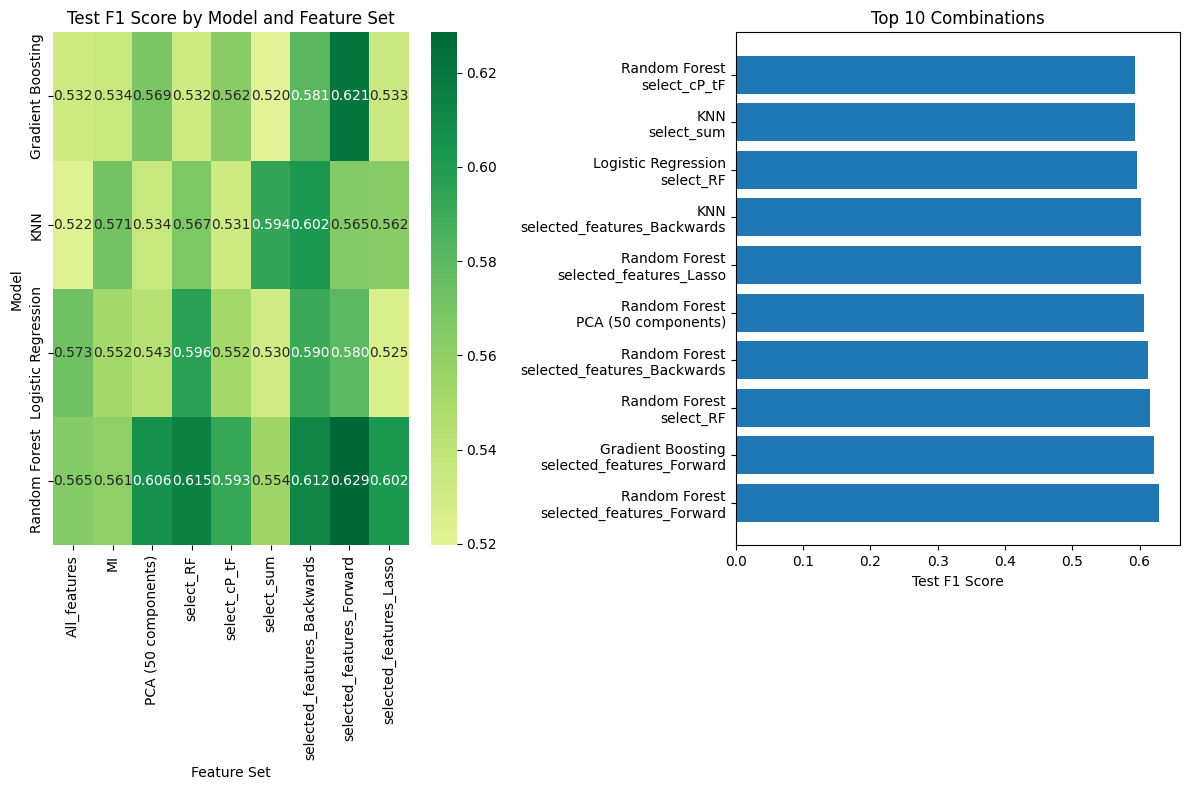


Visualization saved to 'classification_results_visualization.png'


In [ ]:

#Основная функция перебора моделей ипризнаков
# Получаем названия признаков
feature_names = X.columns.tolist()

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA baseline
pca = PCA(n_components=50, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Список моделей для тестирования
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = []

X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)

# Перебор подмножеств признаков для каждой модели
for model_name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {model_name}...")
    print('='*50)
    
    for name, feat_list in feature_sets.items():
        if len(feat_list) == 0:
            continue
        
        # Подмножество признаков
        if isinstance(feat_list, list) and len(feat_list) > 0:
            existing_features = [f for f in feat_list if f in X_train_df.columns]
            if len(existing_features) == 0:
                print(f"Warning: No features found for {name}")
                continue
            X_train_sub = X_train_df[existing_features].values
            X_test_sub = X_test_df[existing_features].values
        else:
            continue
        
        # Обучение модели
        model.fit(X_train_sub, y_train)
        y_pred = model.predict(X_test_sub)
        
        # Получаем вероятности для ROC-AUC
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_test_sub)[:, 1]
        else:
            y_pred_proba = None
        
        # Метрики
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        # AUC-ROC
        if y_pred_proba is not None:
            auc = roc_auc_score(y_test, y_pred_proba)
        else:
            auc = None
        
        # Матрица ошибок
        cm = confusion_matrix(y_test, y_pred)
        
        # Кросс-валидация на train
        cv_scores = cross_val_score(model, X_train_sub, y_train, cv=5, scoring='accuracy')
        cv_f1_scores = cross_val_score(model, X_train_sub, y_train, cv=5, scoring='f1')
        
        results.append({
            'Model': model_name,
            'Feature Set': name,
            'n_features': len(existing_features),
            'CV Accuracy_mean': cv_scores.mean(),
            'CV Accuracy_std': cv_scores.std(),
            'CV F1_mean': cv_f1_scores.mean(),
            'CV F1_std': cv_f1_scores.std(),
            'Test Accuracy': accuracy,
            'Test Precision': precision,
            'Test Recall': recall,
            'Test F1': f1,
            'Test AUC': auc if auc is not None else np.nan,
            'Confusion Matrix': f"[[{cm[0,0]},{cm[0,1]}]\n [{cm[1,0]},{cm[1,1]}]]"
        })
        
        # Вывод прогресса
        if auc is not None:
            print(f"  {name}: F1={f1:.3f}, AUC={auc:.3f} (n={len(existing_features)})")
        else:
            print(f"  {name}: F1={f1:.3f}, AUC=N/A (n={len(existing_features)})")

# Добавляем PCA для каждой модели
print(f"\n{'='*50}")
print("Training with PCA...")
print('='*50)

for model_name, model in models.items():
    # Создаем копию модели для PCA
    model_pca = model.__class__(**model.get_params())
    model_pca.fit(X_train_pca, y_train)
    y_pred = model_pca.predict(X_test_pca)
    
    if hasattr(model_pca, 'predict_proba'):
        y_pred_proba = model_pca.predict_proba(X_test_pca)[:, 1]
    else:
        y_pred_proba = None
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    if y_pred_proba is not None:
        auc = roc_auc_score(y_test, y_pred_proba)
    else:
        auc = None
    
    cm = confusion_matrix(y_test, y_pred)
    
    cv_scores = cross_val_score(model_pca, X_train_pca, y_train, cv=5, scoring='accuracy')
    cv_f1_scores = cross_val_score(model_pca, X_train_pca, y_train, cv=5, scoring='f1')
    
    results.append({
        'Model': model_name,
        'Feature Set': 'PCA (50 components)',
        'n_features': 50,
        'CV Accuracy_mean': cv_scores.mean(),
        'CV Accuracy_std': cv_scores.std(),
        'CV F1_mean': cv_f1_scores.mean(),
        'CV F1_std': cv_f1_scores.std(),
        'Test Accuracy': accuracy,
        'Test Precision': precision,
        'Test Recall': recall,
        'Test F1': f1,
        'Test AUC': auc if auc is not None else np.nan,
        'Confusion Matrix': f"[[{cm[0,0]},{cm[0,1]}]\n [{cm[1,0]},{cm[1,1]}]]"
    })
    
    # Вывод прогресса для PCA
    if auc is not None:
        print(f"  {model_name} (PCA): F1={f1:.3f}, AUC={auc:.3f}")
    else:
        print(f"  {model_name} (PCA): F1={f1:.3f}, AUC=N/A")

# Создание DataFrame с результатами
results_df = pd.DataFrame(results)

# Создаем версию для отображения с форматированием
display_df = results_df.copy()

# Форматирование CV метрик с использованием apply с подачей данных - иначе ошибка, скорее всего можно сделать  проще(!)
def format_cv(row, metric):
    mean = row[f'CV {metric}_mean']
    std = row[f'CV {metric}_std']
    return f"{mean:.3f} ± {std:.3f}"

display_df['CV Accuracy'] = display_df.apply(lambda row: format_cv(row, 'Accuracy'), axis=1)
display_df['CV F1'] = display_df.apply(lambda row: format_cv(row, 'F1'), axis=1)

# Форматирование метрик
display_df['Test Accuracy'] = display_df['Test Accuracy'].apply(lambda x: f"{x:.3f}")
display_df['Test Precision'] = display_df['Test Precision'].apply(lambda x: f"{x:.3f}")
display_df['Test Recall'] = display_df['Test Recall'].apply(lambda x: f"{x:.3f}")
display_df['Test F1'] = display_df['Test F1'].apply(lambda x: f"{x:.3f}")
display_df['Test AUC'] = display_df['Test AUC'].apply(
    lambda x: f"{x:.3f}" if not pd.isna(x) else "N/A"
)

# Сортировка по Test F1 (числовому)
results_df_sorted = results_df.sort_values('Test F1', ascending=False)

# Вывод результатов (с форматированием)
print("\n" + "="*100)
print("SUMMARY (sorted by Test F1)")
print("="*100)
sorted_display = display_df.loc[results_df_sorted.index]
print(sorted_display[['Model', 'Feature Set', 'n_features', 'CV Accuracy', 'CV F1', 
                      'Test Accuracy', 'Test F1', 'Test AUC']].to_string(index=False))

# Сводка по лучшей модели для каждого набора признаков
print("\n" + "="*100)
print("BEST MODEL FOR EACH FEATURE SET")
print("="*100)
best_per_features = results_df.loc[results_df.groupby('Feature Set')['Test F1'].idxmax()]
best_display = display_df.loc[best_per_features.index]
print(best_display[['Feature Set', 'Model', 'Test Accuracy', 'Test F1', 'Test AUC']].to_string(index=False))

# Топ-5 лучших комбинаций
print("\n" + "="*100)
print("TOP-5 BEST COMBINATIONS")
print("="*100)
top5 = results_df.nlargest(5, 'Test F1')
top5_display = display_df.loc[top5.index]
print(top5_display[['Model', 'Feature Set', 'n_features', 'Test F1', 'Test AUC', 'Test Accuracy']].to_string(index=False))

# Сохранение результатов (числовых)
results_df.to_csv('classification_results.csv', index=False)
print("\nResults saved to 'classification_results.csv'")

# Дополнительная статистика по лучшей модели
best_result = results_df.loc[results_df['Test F1'].idxmax()]
best_display_row = display_df.loc[best_result.name]
print("\n" + "="*100)
print(f"BEST MODEL: {best_result['Model']} with {best_result['Feature Set']}")
print("="*100)
print(f"Number of features: {best_result['n_features']}")
print(f"Test Accuracy: {best_display_row['Test Accuracy']}")
print(f"Test Precision: {best_display_row['Test Precision']}")
print(f"Test Recall: {best_display_row['Test Recall']}")
print(f"Test F1: {best_display_row['Test F1']}")
print(f"Test AUC: {best_display_row['Test AUC']}")
print(f"Confusion Matrix:\n{best_result['Confusion Matrix']}")

# Дополнительно: анализ по моделям
print("\n" + "="*100)
print("BEST result per model")
print("="*100)
best_per_model = results_df.loc[results_df.groupby('Model')['Test F1'].idxmax()]
best_per_model_display = display_df.loc[best_per_model.index]
print(best_per_model_display[['Model', 'Feature Set', 'n_features', 'Test F1', 'Test AUC']].to_string(index=False))

# Визуализация результатов (красивое :)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

# Создаем сводную таблицу для тепловой карты
pivot_table = results_df.pivot_table(
    values='Test F1', 
    index='Model', 
    columns='Feature Set'
)

plt.subplot(1, 2, 1)
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='RdYlGn', center=0.5)
plt.title('Test F1 Score by Model and Feature Set')

plt.subplot(1, 2, 2)
# Топ-10 комбинаций
top10 = results_df.nlargest(10, 'Test F1')
bars = plt.barh(range(len(top10)), top10['Test F1'].values)
plt.yticks(range(len(top10)), [f"{row['Model']}\n{row['Feature Set']}" for _, row in top10.iterrows()])
plt.xlabel('Test F1 Score')
plt.title('Top 10 Combinations')

plt.tight_layout()
plt.savefig('classification_results_visualization.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nVisualization saved to 'classification_results_visualization.png'")

**Победитель в отборочном туре - Random Forest  с набором признаков  selected_features_Forward( 80 признаков ) F1=  0.629, AUC =  0.765**

попробуем повысить точность при помощи перебора параметров для Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint


# Выбранные признаки (стандартизацию не будем использовать, так как для алгоритма RF  она не нужна)
selected_features = selected_features_Forward['0'].to_list()
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]



rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

param_dist = {
    "n_estimators": randint(50, 600),    
    "max_depth": randint(5, 35),          
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 15),
    "max_features": ["sqrt", "log2", 0.2, 0.3, 0.5],
    "bootstrap": [True]
}

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=100,                 
    scoring="f1",            
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_selected, y_train)

best_model = search.best_estimator_
print("Best params:", search.best_params_)

# оценка
y_pred = best_model.predict(X_test_selected)
y_proba = best_model.predict_proba(X_test_selected)[:, 1]


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'bootstrap': True, 'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 8, 'min_samples_split': 2, 'n_estimators': 522}


In [31]:
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test F1: 0.5906040268456376


##Итого:

подбор параметров не дал позитивной тенденции в метриках

Лидер остался ```RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')```

F1 = 0.629